**Funnel Analysis On Dataset**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

**Corporate Styling**

In [5]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Everything is fine")

Everything is fine


**Load Dataset**

In [6]:
df = pd.read_csv("funnel_analysis_data.csv")
df

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-03-12 15:51:45,Desktop,North,Social Media,Beauty,0.0,Yes
1,USR00001,SES00001,Add to Cart,2026-03-12 15:56:45,Desktop,North,Social Media,Beauty,0.0,Yes
2,USR00002,SES00002,Browse,2026-02-22 15:00:41,Tablet,West,Social Media,Beauty,0.0,Yes
3,USR00003,SES00003,Browse,2026-03-10 08:38:28,Mobile,South,Organic,Electronics,0.0,Yes
4,USR00003,SES00003,Add to Cart,2026-03-10 08:40:28,Mobile,South,Organic,Electronics,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...
22618,USR09998,SES09998,Browse,2026-03-03 04:22:38,Mobile,West,Organic,Home,0.0,Yes
22619,USR09998,SES09998,Add to Cart,2026-03-03 04:24:38,Mobile,West,Organic,Home,0.0,Yes
22620,USR09999,SES09999,Browse,2026-03-05 00:46:09,Tablet,West,Email,Beauty,0.0,Yes
22621,USR09999,SES09999,Add to Cart,2026-03-05 00:51:09,Tablet,West,Email,Beauty,0.0,Yes


**Basic Steps**

In [7]:
# Top 5 rows
print("Top 5 data\n")
display(df.head())

Top 5 data



,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-03-12 15:51:45,Desktop,North,Social Media,Beauty,0.0,Yes
1,USR00001,SES00001,Add to Cart,2026-03-12 15:56:45,Desktop,North,Social Media,Beauty,0.0,Yes
2,USR00002,SES00002,Browse,2026-02-22 15:00:41,Tablet,West,Social Media,Beauty,0.0,Yes
3,USR00003,SES00003,Browse,2026-03-10 08:38:28,Mobile,South,Organic,Electronics,0.0,Yes
4,USR00003,SES00003,Add to Cart,2026-03-10 08:40:28,Mobile,South,Organic,Electronics,0.0,Yes


In [8]:
# Last 5 rows
df.tail()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
22618,USR09998,SES09998,Browse,2026-03-03 04:22:38,Mobile,West,Organic,Home,0.0,Yes
22619,USR09998,SES09998,Add to Cart,2026-03-03 04:24:38,Mobile,West,Organic,Home,0.0,Yes
22620,USR09999,SES09999,Browse,2026-03-05 00:46:09,Tablet,West,Email,Beauty,0.0,Yes
22621,USR09999,SES09999,Add to Cart,2026-03-05 00:51:09,Tablet,West,Email,Beauty,0.0,Yes
22622,USR10000,SES10000,Browse,2026-02-28 05:03:57,Desktop,East,Google Ads,Home,0.0,Yes


In [9]:
# Random data from dataset
df.sample()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
9690,USR04293,SES04293,Add to Cart,2026-03-01 16:14:49,Desktop,North,Google Ads,Home,0.0,Yes


In [10]:
# Find total column names and number of columns
print(df.columns)
print(f"\nTotal Number of Columns {df.columns.nunique()}")

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='str')

Total Number of Columns 10


In [11]:
# Type of dataset
type(df)

pandas.DataFrame

In [12]:
# Data type of all columns
df.dtypes

User_ID                 str
Session_ID              str
Event                   str
Timestamp               str
Device                  str
Region                  str
Channel                 str
Product_Category        str
Revenue             float64
Bounce_Flag             str
dtype: object

In [13]:
# Timestamp column must be in the datetime type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)

User_ID                        str
Session_ID                     str
Event                          str
Timestamp           datetime64[us]
Device                         str
Region                         str
Channel                        str
Product_Category               str
Revenue                    float64
Bounce_Flag                    str
dtype: object


In [14]:
# Information about all columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22623 entries, 0 to 22622
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           22623 non-null  str           
 1   Session_ID        22623 non-null  str           
 2   Event             22623 non-null  str           
 3   Timestamp         22623 non-null  datetime64[us]
 4   Device            22623 non-null  str           
 5   Region            22623 non-null  str           
 6   Channel           22623 non-null  str           
 7   Product_Category  22623 non-null  str           
 8   Revenue           22623 non-null  float64       
 9   Bounce_Flag       22623 non-null  str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 1.7 MB


In [15]:
# Important information about dataset's numeric columns
df.describe()

,Timestamp,Revenue
count,22623,22623.000000
mean,2026-02-25 21:40:48.752110,101.594911
min,2026-02-10 22:35:08,0.000000
25%,2026-02-18 09:06:12,0.000000
50%,2026-02-25 23:06:22,0.000000
75%,2026-03-05 11:00:48,0.000000
max,2026-03-12 22:33:28,1999.400000
std,NaN,354.268081


In [16]:
# Important information about all columns (object/string types)
df.describe(include="object")

C:\Users\Aditya Bhadauria\AppData\Local\Temp\ipykernel_22472\844205057.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,22623,22623,22623,22623,22623,22623,22623,22623
unique,10000,10000,4,3,4,4,5,2
top,USR00007,SES00007,Browse,Tablet,West,Google Ads,Sports,Yes
freq,4,4,10000,7691,5814,5751,4658,14275


In [17]:
# Shape of dataset
df.shape

(22623, 10)

In [18]:
pd.set_option('display.max_columns', None)
df

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2026-03-12 15:51:45,Desktop,North,Social Media,Beauty,0.0,Yes
1,USR00001,SES00001,Add to Cart,2026-03-12 15:56:45,Desktop,North,Social Media,Beauty,0.0,Yes
2,USR00002,SES00002,Browse,2026-02-22 15:00:41,Tablet,West,Social Media,Beauty,0.0,Yes
3,USR00003,SES00003,Browse,2026-03-10 08:38:28,Mobile,South,Organic,Electronics,0.0,Yes
4,USR00003,SES00003,Add to Cart,2026-03-10 08:40:28,Mobile,South,Organic,Electronics,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...
22618,USR09998,SES09998,Browse,2026-03-03 04:22:38,Mobile,West,Organic,Home,0.0,Yes
22619,USR09998,SES09998,Add to Cart,2026-03-03 04:24:38,Mobile,West,Organic,Home,0.0,Yes
22620,USR09999,SES09999,Browse,2026-03-05 00:46:09,Tablet,West,Email,Beauty,0.0,Yes
22621,USR09999,SES09999,Add to Cart,2026-03-05 00:51:09,Tablet,West,Email,Beauty,0.0,Yes


**Data Preprocessing and Cleaning**

In [19]:
# Check for null and duplicate values

print("\n----Finding Null Values----\n")
null_values = df.isnull().sum()
print(null_values)

print("\n----Finding Duplicate Values----\n")
duplicate_values = df.duplicated().sum()
print(f"Total numbers of duplicate values in this dataset is {duplicate_values}")

print("\n----Total Unique Data----\n")
unique_data = df.nunique()
print(unique_data)


----Finding Null Values----

User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64

----Finding Duplicate Values----

Total numbers of duplicate values in this dataset is 0

----Total Unique Data----

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           22530
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              2079
Bounce_Flag             2
dtype: int64


In [20]:
# Now time for fixing the data and extracting time-based data
# Here we create multiple columns for deep analysis

df['Date'] = df['Timestamp'].dt.date
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Hour'] = df['Timestamp'].dt.hour
df['WeekNumber'] = df['Timestamp'].dt.isocalendar().week

In [21]:
# Add event sequence per session
df['Event_sequence'] = df.groupby('Session_ID').cumcount() + 1

In [22]:
# Preview the first few rows
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber,Event_sequence
0,USR00001,SES00001,Browse,2026-03-12 15:51:45,Desktop,North,Social Media,Beauty,0.0,Yes,2026-03-12,Thursday,15,11,1
1,USR00001,SES00001,Add to Cart,2026-03-12 15:56:45,Desktop,North,Social Media,Beauty,0.0,Yes,2026-03-12,Thursday,15,11,2
2,USR00002,SES00002,Browse,2026-02-22 15:00:41,Tablet,West,Social Media,Beauty,0.0,Yes,2026-02-22,Sunday,15,8,1
3,USR00003,SES00003,Browse,2026-03-10 08:38:28,Mobile,South,Organic,Electronics,0.0,Yes,2026-03-10,Tuesday,8,11,1
4,USR00003,SES00003,Add to Cart,2026-03-10 08:40:28,Mobile,South,Organic,Electronics,0.0,Yes,2026-03-10,Tuesday,8,11,2


In [23]:
# Basic steps
print(f"Total User ID {df['User_ID'].nunique()}")
print(f"\nTotal Session ID {df['Session_ID'].nunique()}")
print(f"\nDate range {df['Date'].min()} to {df['Date'].max()}")

Total User ID 10000

Total Session ID 10000

Date range 2026-02-10 to 2026-03-12


**Funnel Stage Definition and Session-Level Aggregation**

In [24]:
# Define funnel stages in order
funnel_stages = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

# Create session-level summary
session_summary = df.groupby('Session_ID').agg({
    'User_ID': 'first',
    'Timestamp': ['min', 'max'],
    'Event': lambda x: list(x),
    'Device': 'first',
    'Region': 'first',
    'Channel': 'first',
    'Product_Category': 'first',
    'Revenue': 'max',
    'Bounce_Flag': 'first'
}).reset_index()

# Flatten column names
session_summary.columns = [
    'Session_ID', 'User_ID', 'Session_Start', 'Session_End',
    'Event_Sequence', 'Device', 'Region', 'Channel',
    'Product_Category', 'Revenue', 'Bounce_Flag'
]

# Calculate session duration in minutes
session_summary['Session_Duration_Min'] = (
    session_summary['Session_End'] - session_summary['Session_Start']
).dt.total_seconds() / 60

# Identify maximum funnel stage reached for each session
def get_max_funnel_stage(events):
    stage_values = {stage: i for i, stage in enumerate(funnel_stages)}
    max_stage_index = -1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]
    return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'

session_summary['Max_Funnel_Stage'] = session_summary['Event_Sequence'].apply(get_max_funnel_stage)

print("🧾 Session Summary Created:")
display(session_summary.head())


🧾 Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2026-03-12 15:51:45,2026-03-12 15:56:45,"[Browse, Add to Cart]",Desktop,North,Social Media,Beauty,0.0,Yes,5.0,Add to Cart
1,SES00002,USR00002,2026-02-22 15:00:41,2026-02-22 15:00:41,[Browse],Tablet,West,Social Media,Beauty,0.0,Yes,0.0,Browse
2,SES00003,USR00003,2026-03-10 08:38:28,2026-03-10 08:42:28,"[Browse, Add to Cart, Checkout]",Mobile,South,Organic,Electronics,0.0,Yes,4.0,Checkout
3,SES00004,USR00004,2026-02-21 07:23:04,2026-02-21 07:26:04,"[Browse, Add to Cart]",Mobile,East,Google Ads,Home,0.0,Yes,3.0,Add to Cart
4,SES00005,USR00005,2026-02-21 22:35:01,2026-02-21 22:39:01,"[Browse, Add to Cart, Checkout]",Tablet,West,Organic,Electronics,0.0,Yes,4.0,Checkout


**Overall Funnel Analysis**

In [25]:
# Calculate overall funnel metrics
funnel_metrics = []
for i, stage in enumerate(funnel_stages):
    if i == 0:
        # For Browse stage, count all sessions
        count = len(session_summary)
    else:
        # For other stages, count sessions that reached at least this stage
        count = len(session_summary[session_summary['Max_Funnel_Stage'].isin(funnel_stages[i:])])

    funnel_metrics.append({
        'Stage': stage,
        'Sessions': count,
        'Stage_Order': i
    })

funnel_df = pd.DataFrame(funnel_metrics)

# Calculate conversion rates
funnel_df['Conversion_Rate'] = (funnel_df['Sessions'] / funnel_df['Sessions'].iloc[0] * 100).round(2)
funnel_df['Drop_Off_Rate'] = (1 - funnel_df['Sessions'] / funnel_df['Sessions'].shift(1)) * 100
funnel_df['Drop_Off_Rate'] = funnel_df['Drop_Off_Rate'].round(2)

# Fix first row drop-off rate safely using .loc
funnel_df.loc[0, 'Drop_Off_Rate'] = 0

print("📊 Overall Funnel Analysis:")
display(funnel_df)

# Revenue analysis
revenue_stats = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'].agg({
    'Revenue': ['sum', 'mean', 'count']
}).round(2)

print("\n💰 Revenue Analysis:")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:,.2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1,0]:,.2f}")
print(f"Total Orders: {revenue_stats.iloc[2,0]:,}")

📊 Overall Funnel Analysis:


,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_Off_Rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,7062,1,70.62,29.38
2,Checkout,3474,2,34.74,50.81
3,Purchase,2087,3,20.87,39.93



💰 Revenue Analysis:
Total Revenue: $2,298,381.68
Average Order Value: $1,101.28
Total Orders: 2,087.0


**Visualization - Overall Funnel**

In [26]:
# Create comprehensive funnel visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Funnel Conversion Rates', 'Stage-to-Stage Drop-off',
                    'Revenue by Funnel Stage', 'Session Duration by Stage'),
    specs=[[{'secondary_y': False}, {'secondary_y': False}],
           [{'secondary_y': False}, {'secondary_y': False}]]
)

# Funnel conversion rates
fig.add_trace(
    go.Bar(x=funnel_df['Stage'], y=funnel_df['Sessions'],
           text=funnel_df['Sessions'], textposition='auto',
           name='Sessions', marker_color='lightblue'),
    row=1, col=1
)

# Drop-off rates
fig.add_trace(
    go.Scatter(x=funnel_df['Stage'], y=funnel_df['Drop_Off_Rate'],
               mode='lines+markers+text', text=funnel_df['Drop_Off_Rate'],
               textposition='top center', name='Drop-off Rate (%)',
               line=dict(color='red', width=3)),
    row=1, col=2, secondary_y=False
)

# Revenue by stage
revenue_by_stage = session_summary.groupby('Max_Funnel_Stage')['Revenue'].sum().reset_index()
fig.add_trace(
    go.Bar(x=revenue_by_stage['Max_Funnel_Stage'], y=revenue_by_stage['Revenue'],
           text=[f'${x:.0f}' for x in revenue_by_stage['Revenue']],
           textposition='auto', name='Revenue', marker_color='green'),
    row=2, col=1
)

# Session duration by stage
duration_by_stage = session_summary.groupby('Max_Funnel_Stage')['Session_Duration_Min'].mean().reset_index()
fig.add_trace(
    go.Bar(x=duration_by_stage['Max_Funnel_Stage'], y=duration_by_stage['Session_Duration_Min'],
           text=duration_by_stage['Session_Duration_Min'].round(2),
           textposition='auto', name='Avg Session Duration (min)',
           marker_color='orange'),
    row=2, col=2
)

# Layout settings
fig.update_layout(height=800, title_text="Comprehensive Funnel Analysis Dashboard", showlegend=False)
fig.show()

**Channel Performence Analysis**

🔍 Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate,Add to Cart_Sessions,Add to Cart_Rate,Checkout_Sessions,Checkout_Rate,Purchase_Sessions,Purchase_Rate,Total_Revenue,AOV,Conversion_Rate
0,Social Media,2461,2461,100.0,1729,70.26,836,33.97,512,20.80,570449.80,1114.16,20.80
1,Organic,2540,2540,100.0,1810,71.26,864,34.02,506,19.92,572290.78,1131.01,19.92
2,Google Ads,2557,2557,100.0,1777,69.50,872,34.10,545,21.31,587816.51,1078.56,21.31
3,Email,2442,2442,100.0,1746,71.50,902,36.94,524,21.46,567824.59,1083.63,21.46


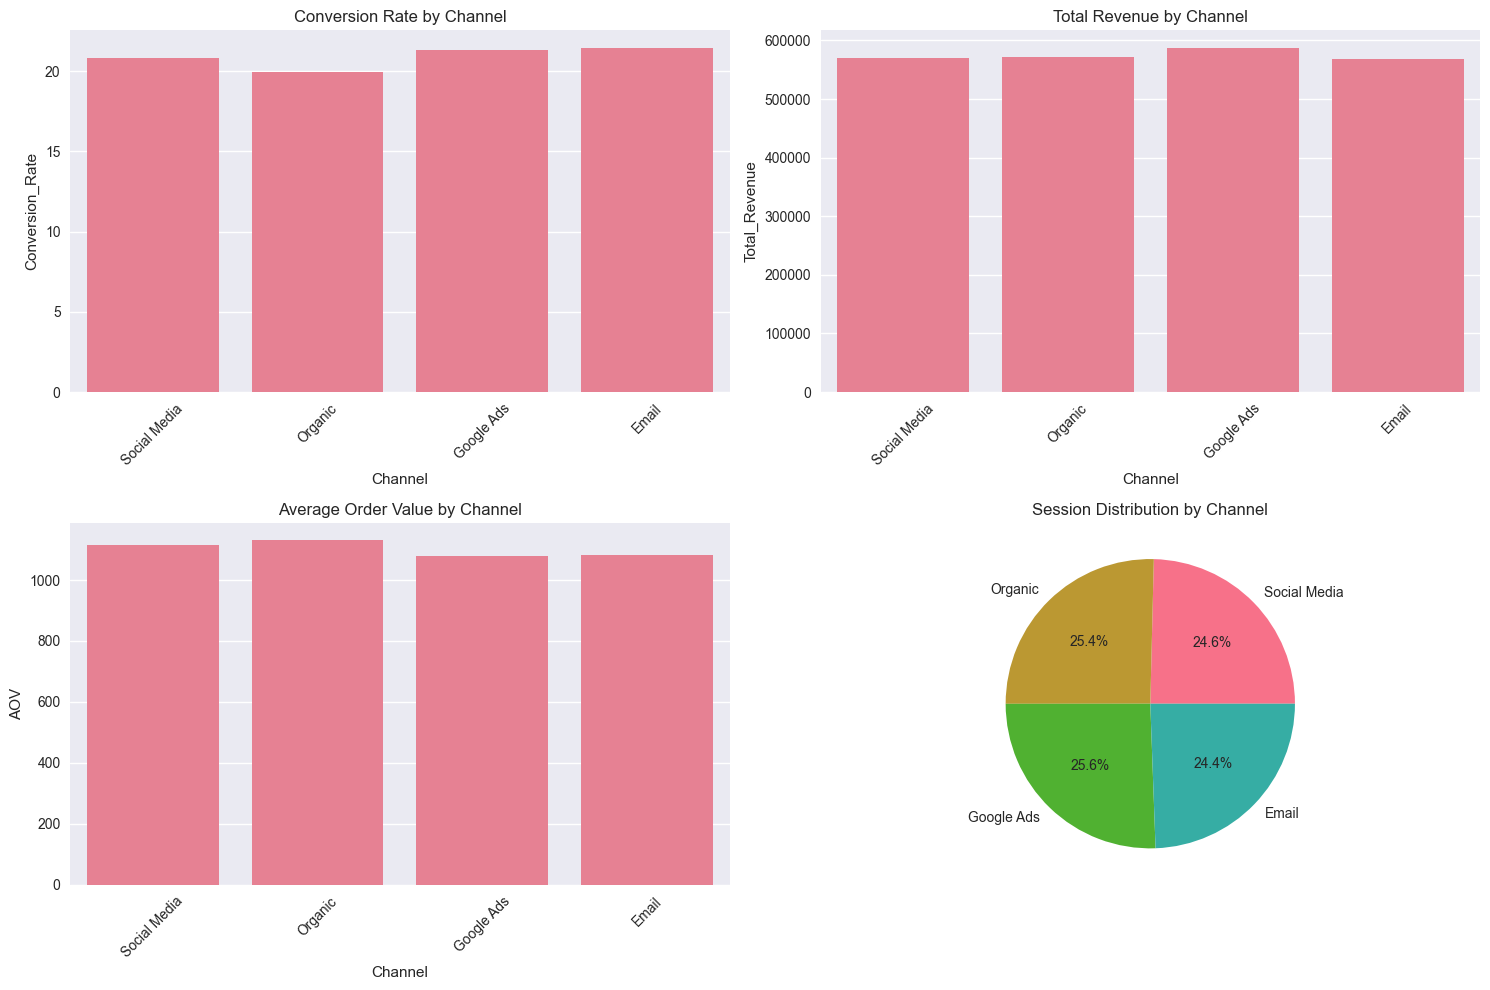

In [27]:
# Funnel analysis by channel
channel_funnel = []

for channel in df['Channel'].unique():
    channel_sessions = session_summary[session_summary['Channel'] == channel]
    total_sessions = len(channel_sessions)

    if total_sessions > 0:
        channel_metrics = {'Channel': channel, 'Total_Sessions': total_sessions}

        for i, stage in enumerate(funnel_stages):
            if i == 0:
                count = total_sessions
            else:
                count = len(channel_sessions[channel_sessions['Max_Funnel_Stage'].isin(funnel_stages[i:])])

            channel_metrics[f'{stage}_Sessions'] = count
            channel_metrics[f'{stage}_Rate'] = (count / total_sessions * 100)

        # Revenue metrics
        purchase_sessions = channel_sessions[channel_sessions['Max_Funnel_Stage'] == 'Purchase']
        channel_metrics['Total_Revenue'] = purchase_sessions['Revenue'].sum()
        channel_metrics['AOV'] = purchase_sessions['Revenue'].mean() if len(purchase_sessions) > 0 else 0
        channel_metrics['Conversion_Rate'] = (len(purchase_sessions) / total_sessions * 100)

        channel_funnel.append(channel_metrics)

channel_df = pd.DataFrame(channel_funnel)

print("🔍 Channel Performance Analysis:")
display(channel_df.round(2))

# Visualize channel performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Conversion rates by channel
sns.barplot(data=channel_df, x='Channel', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion Rate by Channel')
ax1.tick_params(axis='x', rotation=45)

# Total revenue by channel
sns.barplot(data=channel_df, x='Channel', y='Total_Revenue', ax=ax2)
ax2.set_title('Total Revenue by Channel')
ax2.tick_params(axis='x', rotation=45)

# AOV by channel
sns.barplot(data=channel_df, x='Channel', y='AOV', ax=ax3)
ax3.set_title('Average Order Value by Channel')
ax3.tick_params(axis='x', rotation=45)

# Session distribution by channel
channel_df['Session_Percentage'] = (channel_df['Total_Sessions'] / channel_df['Total_Sessions'].sum() * 100)
ax4.pie(channel_df['Session_Percentage'], labels=channel_df['Channel'], autopct='%1.1f%%')
ax4.set_title('Session Distribution by Channel')

plt.tight_layout()
plt.show()

**Regional Analysis**

🌐 Regional Performance:


,Total_Sessions,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2526,579173.19,4.329770,519,20.55,1115.94
North,2504,559752.54,4.388578,507,20.25,1104.05
South,2428,560273.74,4.413097,509,20.96,1100.73
West,2542,599182.21,4.516129,552,21.72,1085.48


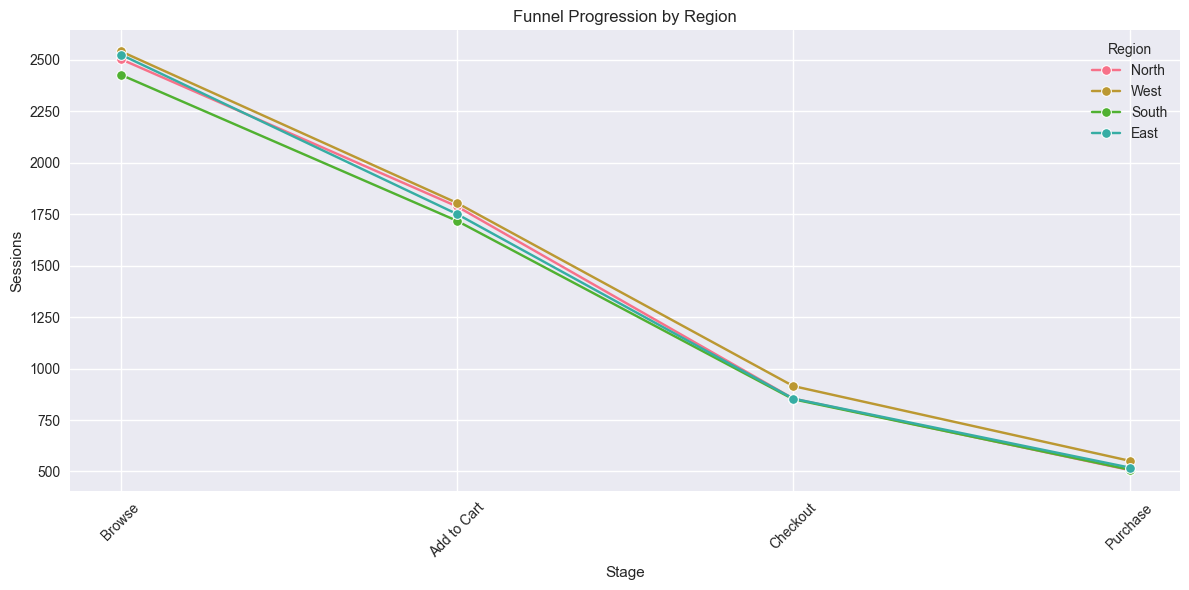

In [28]:
# Regional performance analysis
regional_analysis = session_summary.groupby('Region').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean'
}).rename(columns={'Session_ID': 'Total_Sessions', 'Revenue': 'Total_Revenue'})

# Add conversion rates by region
regional_conversion = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby('Region').size()
regional_analysis['Converted_Sessions'] = regional_conversion
regional_analysis['Conversion_Rate'] = (regional_analysis['Converted_Sessions'] / regional_analysis['Total_Sessions'] * 100).round(2)
regional_analysis['AOV'] = (regional_analysis['Total_Revenue'] / regional_analysis['Converted_Sessions']).round(2)

print("🌐 Regional Performance:")
display(regional_analysis)

# Regional funnel visualization
regional_funnel_data = []
for region in df['Region'].unique():
    region_sessions = session_summary[session_summary['Region'] == region]
    for stage in funnel_stages:
        if stage == 'Browse':
            count = len(region_sessions)
        else:
            count = len(region_sessions[region_sessions['Max_Funnel_Stage'].isin(funnel_stages[funnel_stages.index(stage):])])
        regional_funnel_data.append({'Region': region, 'Stage': stage, 'Sessions': count})

regional_funnel_df = pd.DataFrame(regional_funnel_data)

plt.figure(figsize=(12, 6))
sns.lineplot(data=regional_funnel_df, x='Stage', y='Sessions', hue='Region', marker='o')
plt.title('Funnel Progression by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Device and Product Category Analysis**

📱 Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3292,767906.17,4.358445,687,20.87,1117.77
Mobile,3353,755845.28,4.360573,682,20.34,1108.28
Tablet,3355,774630.23,4.516244,718,21.40,1078.87


🛍️ Product Category Performance:


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_Per_Session
Product_Category,,,,,,
Beauty,1994,472377.29,440,22.07,1073.58,236.90
Electronics,2038,446144.14,413,20.26,1080.25,218.91
Fashion,1908,441818.73,389,20.39,1135.78,231.56
Home,2007,455088.17,416,20.73,1093.96,226.75
Sports,2053,482953.35,429,20.90,1125.77,235.24


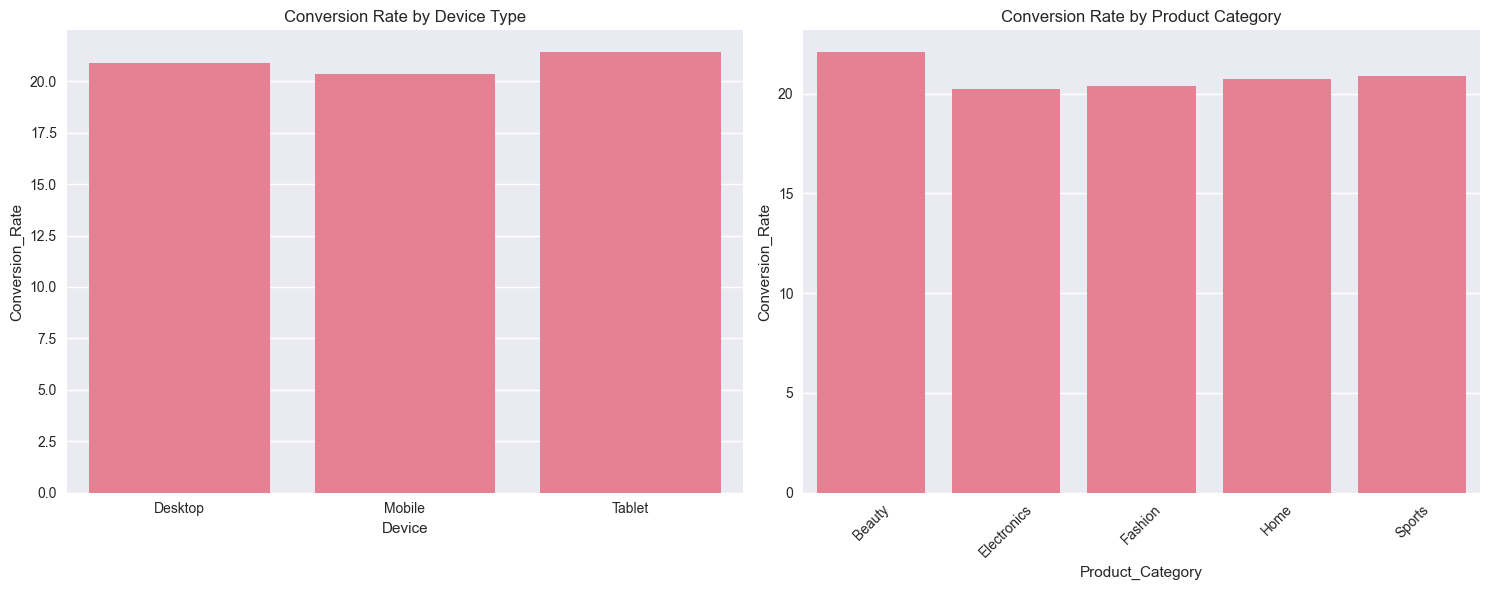

In [29]:
# Device performance
device_analysis = session_summary.groupby('Device').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID': 'Total_Sessions', 'Max_Funnel_Stage': 'Purchases'})

device_analysis['Conversion_Rate'] = (device_analysis['Purchases'] / device_analysis['Total_Sessions'] * 100).round(2)
device_analysis['AOV'] = (device_analysis['Revenue'] / device_analysis['Purchases']).round(2)

print("📱 Device Performance:")
display(device_analysis)

# Product category performance
product_analysis = session_summary.groupby('Product_Category').agg({
    'Session_ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns={'Session_ID': 'Total_Sessions', 'Max_Funnel_Stage': 'Purchases'})

product_analysis['Conversion_Rate'] = (product_analysis['Purchases'] / product_analysis['Total_Sessions'] * 100).round(2)
product_analysis['AOV'] = (product_analysis['Revenue'] / product_analysis['Purchases']).round(2)
product_analysis['Revenue_Per_Session'] = (product_analysis['Revenue'] / product_analysis['Total_Sessions']).round(2)

print("🛍️ Product Category Performance:")
display(product_analysis)

# Combined visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Device performance conversion rates
sns.barplot(data=device_analysis.reset_index(), x='Device', y='Conversion_Rate', ax=ax1)
ax1.set_title('Conversion Rate by Device Type')

# Product category conversion rates
sns.barplot(data=product_analysis.reset_index(), x='Product_Category', y='Conversion_Rate', ax=ax2)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Time-Based Analysis**

📈 Daily Performance Trends


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
Date,,,,,
2026-03-03,331,331,81972.64,70,21.15
2026-03-04,317,317,83307.53,71,22.40
2026-03-05,339,339,82179.23,76,22.42
2026-03-06,360,360,77180.64,79,21.94
2026-03-07,320,320,72904.79,66,20.62
2026-03-08,327,327,72993.27,62,18.96
2026-03-09,357,357,73259.64,69,19.33
2026-03-10,321,321,73975.26,65,20.25
2026-03-11,322,322,56088.08,53,16.46


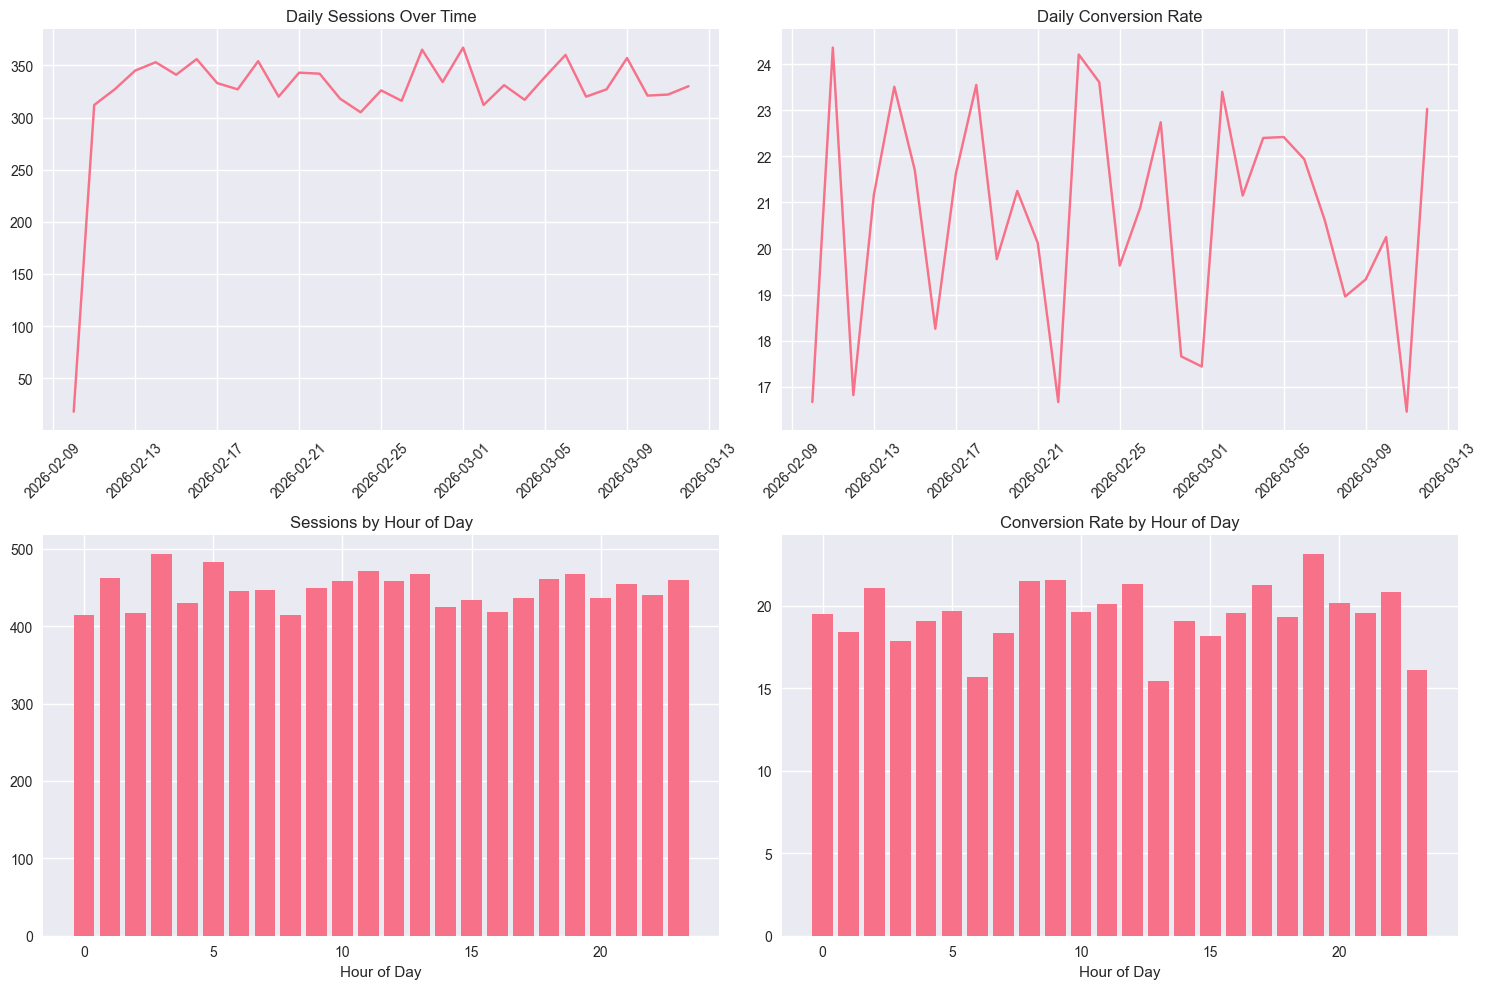

In [30]:
# Daily trends
daily_metrics = df.groupby('Date').agg({
    'Session_ID': 'nunique',
    'User_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Daily_Sessions', 'User_ID': 'Daily_Users'})

# Add conversion rates daily
daily_conversions = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby(
    session_summary['Session_Start'].dt.date
).size()
daily_metrics['Daily_Conversions'] = daily_conversions
daily_metrics['Daily_Conversion_Rate'] = (daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions'] * 100).round(2)

print("📈 Daily Performance Trends")
display(daily_metrics.tail(10))

# Hourly patterns
hourly_sessions = df.groupby('Hour').agg({
    'Session_ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session_ID': 'Hourly_Sessions'})

hourly_conversions = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'].copy()
hourly_conversions['Hour'] = hourly_conversions['Session_Start'].dt.hour
hourly_conversion_counts = hourly_conversions.groupby('Hour').size()
hourly_sessions['Hourly_Conversions'] = hourly_conversion_counts
hourly_sessions['Hourly_Conversion_Rate'] = (hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions'] * 100).round(2)

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Daily sessions
ax1.plot(daily_metrics.index, daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions Over Time')
ax1.tick_params(axis='x', rotation=45)

# Daily conversion rate
ax2.plot(daily_metrics.index, daily_metrics['Daily_Conversion_Rate'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation=45)

# Hourly session pattern
ax3.bar(hourly_sessions.index, hourly_sessions['Hourly_Sessions'])
ax3.set_xlabel('Hour of Day')
ax3.set_title('Sessions by Hour of Day')

# Hourly conversion rate
ax4.bar(hourly_sessions.index, hourly_sessions['Hourly_Conversion_Rate'])
ax4.set_title('Conversion Rate by Hour of Day')
ax4.set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

**Advanced Funnel Metrics and KPIs**

In [31]:
# Calculate advanced metrics
print("🔑 KEY PERFORMANCE INDICATORS (KPIs)")
print("="*50)

# Overall KPIs
total_sessions = len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'])
overall_conversion_rate = (total_orders / total_sessions * 100)

print(f"📈 Overall Conversion Rate: {overall_conversion_rate:.2f}%")
print(f"💰 Total Revenue: ${total_revenue:.2f}")
print(f"🛒 Average Order Value: ${(total_revenue / total_orders):.2f}")
print(f"👥 Total Sessions: {total_sessions:,}")
print(f"📦 Total Orders: {total_orders:,}")

# Funnel efficiency metrics
browse_to_cart = (funnel_df.iloc[1]['Sessions'] / funnel_df.iloc[0]['Sessions'] * 100)
cart_to_checkout = (funnel_df.iloc[2]['Sessions'] / funnel_df.iloc[1]['Sessions'] * 100)
checkout_to_purchase = (funnel_df.iloc[3]['Sessions'] / funnel_df.iloc[2]['Sessions'] * 100)

print("\n🔄 Stage-to-Stage Conversion Rates:")
print(f"🛍️ Browse → Add to Cart: {browse_to_cart:.2f}%")
print(f"🛒 Add to Cart → Checkout: {cart_to_checkout:.2f}%")
print(f"💳 Checkout → Purchase: {checkout_to_purchase:.2f}%")

# Revenue per session at each stage
revenue_per_browse = total_revenue / funnel_df.iloc[0]['Sessions']
revenue_per_cart = total_revenue / funnel_df.iloc[1]['Sessions']
revenue_per_checkout = total_revenue / funnel_df.iloc[2]['Sessions']

print("\n💸 Revenue per Session by Stage:")
print(f"🔍 Per Browse Session: ${revenue_per_browse:.2f}")
print(f"🛒 Per Cart Session: ${revenue_per_cart:.2f}")
print(f"💳 Per Checkout Session: ${revenue_per_checkout:.2f}")

# Bounce rate analysis
bounce_sessions = session_summary[session_summary['Bounce_Flag'] == 'Yes']
bounce_rate = (len(bounce_sessions) / total_sessions * 100)
print(f"\n🚪 Bounce Rate: {bounce_rate:.2f}%")

# Session duration analysis
avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f"\n⏱️ Average Session Duration: {avg_session_duration:.2f} minutes")

🔑 KEY PERFORMANCE INDICATORS (KPIs)
📈 Overall Conversion Rate: 20.87%
💰 Total Revenue: $2298381.68
🛒 Average Order Value: $1101.28
👥 Total Sessions: 10,000
📦 Total Orders: 2,087

🔄 Stage-to-Stage Conversion Rates:
🛍️ Browse → Add to Cart: 70.62%
🛒 Add to Cart → Checkout: 49.19%
💳 Checkout → Purchase: 60.07%

💸 Revenue per Session by Stage:
🔍 Per Browse Session: $229.84
🛒 Per Cart Session: $325.46
💳 Per Checkout Session: $661.60

🚪 Bounce Rate: 79.13%

⏱️ Average Session Duration: 4.41 minutes


**Strategic Recommendations**

In [32]:
# Generate actionable insights
print("💡 STRATEGIC RECOMMENDATIONS")
print("*" * 50)

# Identify biggest drop-off points
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_Off_Rate'].idxmax()]
print(f"📉 BIGGEST DROP-OFF: {max_dropoff_stage['Stage']} stage with {max_dropoff_stage['Drop_Off_Rate']}% drop-off")

# Best performing channel
best_channel = channel_df.loc[channel_df['Conversion_Rate'].idxmax()]
print(f"📢 BEST PERFORMING CHANNEL: {best_channel['Channel']} with {best_channel['Conversion_Rate']:.2f}% conversion")

# Best performing region
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate'].idxmax()]
print(f"🌐 BEST PERFORMING REGION: {best_region.name} with {best_region['Conversion_Rate']:.2f}% conversion")

# Best performing product category
best_category = product_analysis.loc[product_analysis['Conversion_Rate'].idxmax()]
print(f"🛍️ BEST PERFORMING CATEGORY: {best_category.name} with {best_category['Conversion_Rate']:.2f}% conversion")

print("\n🔧 RECOMMENDED ACTIONS:")
print(f"1. Address {max_dropoff_stage['Stage']} stage drop-off through UX improvements")
print(f"2. Allocate more budget to {best_channel['Channel']} channel")
print(f"3. Replicate {best_region.name} region strategies in underperforming regions")
print(f"4. Promote {best_category.name} category to improve overall conversion")
print(f"5. Focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_Off_Rate']}% of users")

# Calculate potential revenue opportunities
cart_abandonment_opportunity = funnel_df.iloc[2]['Sessions'] * product_analysis['AOV'].mean()
print("\n💰 REVENUE OPPORTUNITY:")
print(f"   Cart abandonment recovery: ${cart_abandonment_opportunity:,.2f} potential revenue")


💡 STRATEGIC RECOMMENDATIONS
**************************************************
📉 BIGGEST DROP-OFF: Checkout stage with 50.81% drop-off
📢 BEST PERFORMING CHANNEL: Email with 21.46% conversion
🌐 BEST PERFORMING REGION: West with 21.72% conversion
🛍️ BEST PERFORMING CATEGORY: Beauty with 22.07% conversion

🔧 RECOMMENDED ACTIONS:
1. Address Checkout stage drop-off through UX improvements
2. Allocate more budget to Email channel
3. Replicate West region strategies in underperforming regions
4. Promote Beauty category to improve overall conversion
5. Focus on cart abandonment recovery for 50.81% of users

💰 REVENUE OPPORTUNITY:
   Cart abandonment recovery: $3,827,889.43 potential revenue


**Export Results**

✅ Analysis complete! Report exported to 'funnel_analysis_report.xlsx'
✅ Key visualizations saved!


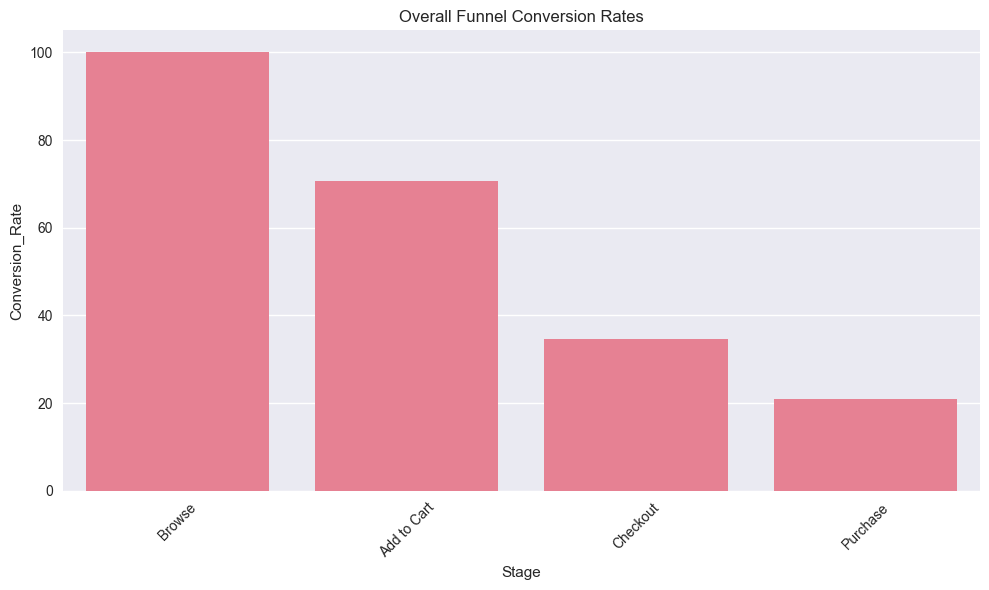

In [34]:
# Create comprehensive report
report_data = {
    'Overall_Funnel': funnel_df,
    'Channel_Performance': channel_df,
    'Regional_Analysis': regional_analysis,
    'Device_Performance': device_analysis,
    'Product_Performance': product_analysis,
    'Daily_Trends': daily_metrics,
    'Hourly_Patterns': hourly_sessions
}

# Export to Excel for corporate reporting
with pd.ExcelWriter('funnel_analysis_report.xlsx') as writer:
    for sheet_name, data in report_data.items():
        data.to_excel(writer, sheet_name=sheet_name, index=False)
print("✅ Analysis complete! Report exported to 'funnel_analysis_report.xlsx'")

# Save key visualizations
plt.figure(figsize=(10, 6))
sns.barplot(data=funnel_df, x='Stage', y='Conversion_Rate')
plt.title('Overall Funnel Conversion Rates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('funnel_conversion_rates.png', dpi=300, bbox_inches='tight')
print("✅ Key visualizations saved!")